# 09 — Validasi Model Klasifikasi Jenis Awan

Notebook ini digunakan untuk melakukan validasi mendalam terhadap checkpoint
terbaik yang dihasilkan oleh `08_training_model.ipynb`.

Validasi menggunakan split:

```text
dataset/source/val/


---

# BAGIAN 2 — Mengimpor Library

Buat sel **Markdown**:

```markdown

## Mengimpor Library

Library yang digunakan mencakup PyTorch, timm, Albumentations, scikit-learn,
Pandas, NumPy, PIL, dan Matplotlib.

Seaborn tidak digunakan agar notebook tetap dapat berjalan apabila dependency
tersebut belum tersedia pada environment.

In [15]:
from pathlib import Path
from datetime import datetime

import hashlib
import json
import random
import re
import sys
import time

try:
    import albumentations as A
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import torch
    import torch.nn as nn
  

    from albumentations.pytorch import ToTensorV2
    from IPython.display import display
    from PIL import Image
    from sklearn.metrics import (
        accuracy_score,
        balanced_accuracy_score,
        cohen_kappa_score,
        confusion_matrix,
        f1_score,
        log_loss,
        matthews_corrcoef,
        precision_recall_fscore_support,
        roc_auc_score,
        top_k_accuracy_score,
    )
    from torch.utils.data import DataLoader
    from torchvision.datasets import ImageFolder
    from tqdm.auto import tqdm

except ImportError as exc:
    raise ImportError(
        "Dependency validasi belum lengkap.\n\n"
        "Aktifkan .venv, kemudian jalankan melalui terminal VS Code:\n\n"
        r".\.venv\Scripts\python.exe -m pip install -r requirements.txt"
    ) from exc


pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.precision", 6)


print(f"Python         : {sys.version.split()[0]}")
print(f"NumPy          : {np.__version__}")
print(f"Pandas         : {pd.__version__}")
print(f"PyTorch        : {torch.__version__}")
print(f"timm           : {timm.__version__}")
print(f"Albumentations : {A.__version__}")
print(f"CUDA tersedia  : {torch.cuda.is_available()}")

Python         : 3.11.9
NumPy          : 2.4.6
Pandas         : 3.0.5
PyTorch        : 2.11.0+cu128
timm           : 1.0.28
Albumentations : 2.0.8
CUDA tersedia  : True


## Menentukan Lokasi Project

Lokasi project ditentukan secara dinamis agar notebook dapat dijalankan dari:

- folder utama project; atau
- folder `notebooks`.

Notebook tidak menggunakan path absolut Docker `/app`.

In [16]:
CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR


DATASET_DIR = PROJECT_DIR / "dataset"
SOURCE_DIR = DATASET_DIR / "source"
PROCESSED_DIR = DATASET_DIR / "processed"

MODELS_DIR = PROJECT_DIR / "models"
LOGS_DIR = PROJECT_DIR / "logs"

VAL_DIR = SOURCE_DIR / "val"

DATALOADER_CONFIG_PATH = (
    PROCESSED_DIR
    / "dataloader_config.json"
)

MODEL_CONFIG_PATH = (
    PROCESSED_DIR
    / "model_config.json"
)

EVAL_TRANSFORM_PATH = (
    PROCESSED_DIR
    / "eval_transform.json"
)


path_table = pd.DataFrame({
    "Nama": [
        "PROJECT_DIR",
        "VAL_DIR",
        "PROCESSED_DIR",
        "MODELS_DIR",
        "LOGS_DIR",
        "DATALOADER_CONFIG_PATH",
        "MODEL_CONFIG_PATH",
        "EVAL_TRANSFORM_PATH",
    ],
    "Path": [
        PROJECT_DIR,
        VAL_DIR,
        PROCESSED_DIR,
        MODELS_DIR,
        LOGS_DIR,
        DATALOADER_CONFIG_PATH,
        MODEL_CONFIG_PATH,
        EVAL_TRANSFORM_PATH,
    ],
})

path_table["Ada"] = (
    path_table["Path"]
    .map(Path.exists)
)

display(path_table)

,Nama,Path,Ada
0,PROJECT_DIR,D:\n8n-logsiswaparalayang\cloud-classification,True
1,VAL_DIR,D:\n8n-logsiswaparalayang\cloud-classification\dataset\source\val,True
2,PROCESSED_DIR,D:\n8n-logsiswaparalayang\cloud-classification\dataset\processed,True
3,MODELS_DIR,D:\n8n-logsiswaparalayang\cloud-classification\models,True
4,LOGS_DIR,D:\n8n-logsiswaparalayang\cloud-classification\logs,True
5,DATALOADER_CONFIG_PATH,D:\n8n-logsiswaparalayang\cloud-classification\dataset\processed\dataloader_config.json,True
6,MODEL_CONFIG_PATH,D:\n8n-logsiswaparalayang\cloud-classification\dataset\processed\model_config.json,True
7,EVAL_TRANSFORM_PATH,D:\n8n-logsiswaparalayang\cloud-classification\dataset\processed\eval_transform.json,True


In [17]:
SRC_DIR = (
    PROJECT_DIR
    / "src"
)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(SRC_DIR),
    )


from model_factory import (
    create_cloud_classifier,
)

## Memeriksa Prasyarat

Notebook validasi hanya dapat dijalankan apabila:

- validation dataset sudah tersedia;
- `dataloader_config.json` sudah tersedia;
- `model_config.json` sudah tersedia;
- `eval_transform.json` sudah tersedia;
- checkpoint terbaik hasil training sudah tersedia.

Folder test sengaja tidak didefinisikan dan tidak diperiksa.

In [18]:
required_directories = [
    PROJECT_DIR,
    DATASET_DIR,
    SOURCE_DIR,
    PROCESSED_DIR,
    MODELS_DIR,
    LOGS_DIR,
    VAL_DIR,
]

required_files = [
    DATALOADER_CONFIG_PATH,
    MODEL_CONFIG_PATH,
    EVAL_TRANSFORM_PATH,
]


missing_directories = [
    path
    for path in required_directories
    if not path.is_dir()
]

missing_files = [
    path
    for path in required_files
    if not path.is_file()
]


if missing_directories:
    formatted_paths = "\n".join(
        f"- {path}"
        for path in missing_directories
    )

    raise FileNotFoundError(
        "Folder prasyarat belum tersedia:\n"
        f"{formatted_paths}"
    )


if missing_files:
    formatted_paths = "\n".join(
        f"- {path}"
        for path in missing_files
    )

    raise FileNotFoundError(
        "Artefak tahap sebelumnya belum tersedia:\n"
        f"{formatted_paths}\n\n"
        "Jalankan notebook 05, 06, 07, dan 08 secara berurutan."
    )


print("Seluruh prasyarat awal validasi tersedia.")
print("Data test tidak diperiksa dan tidak digunakan.")

Seluruh prasyarat awal validasi tersedia.
Data test tidak diperiksa dan tidak digunakan.


## Membaca Konfigurasi Tahap Sebelumnya

Notebook membaca konfigurasi yang sudah tersedia sehingga nama model, jumlah
kelas, ukuran input, batch size, seed, dropout, dan pemetaan kelas tidak ditulis
ulang secara manual.

In [19]:
with DATALOADER_CONFIG_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    dataloader_config = json.load(file)


with MODEL_CONFIG_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    model_config = json.load(file)


required_model_keys = {
    "model_name",
    "num_classes",
    "class_to_idx",
    "input_shape",
    "dropout_rate",
}


missing_model_keys = (
    required_model_keys
    - set(model_config.keys())
)


if missing_model_keys:
    raise KeyError(
        "model_config.json belum lengkap. "
        "Kunci yang hilang: "
        f"{sorted(missing_model_keys)}"
    )


print("Konfigurasi DataLoader dan model berhasil dibaca.")

Konfigurasi DataLoader dan model berhasil dibaca.


In [20]:
MODEL_NAME = str(
    model_config["model_name"]
)

NUM_CLASSES = int(
    model_config["num_classes"]
)

CLASS_TO_IDX = {
    str(class_name): int(class_idx)
    for class_name, class_idx
    in model_config["class_to_idx"].items()
}

CLASS_TO_IDX = dict(
    sorted(
        CLASS_TO_IDX.items(),
        key=lambda item: item[1],
    )
)

IDX_TO_CLASS = {
    class_idx: class_name
    for class_name, class_idx
    in CLASS_TO_IDX.items()
}

CLASS_NAMES = [
    IDX_TO_CLASS[class_idx]
    for class_idx in range(NUM_CLASSES)
]

LABEL_IDS = np.arange(
    NUM_CLASSES,
    dtype=np.int64,
)


INPUT_CHANNELS, IMAGE_HEIGHT, IMAGE_WIDTH = map(
    int,
    model_config["input_shape"],
)

DROPOUT_RATE = float(
    model_config.get(
        "dropout_rate",
        0.0,
    )
)

SEED = int(
    dataloader_config.get(
        "random_seed",
        model_config.get("seed", 42),
    )
)

BATCH_SIZE = int(
    dataloader_config.get(
        "batch_size",
        32,
    )
)

NUM_WORKERS = int(
    dataloader_config.get(
        "num_workers",
        0,
    )
)


if NUM_CLASSES < 2:
    raise ValueError(
        "Validasi klasifikasi memerlukan minimal dua kelas."
    )


expected_indices = list(
    range(NUM_CLASSES)
)

observed_indices = list(
    CLASS_TO_IDX.values()
)


if observed_indices != expected_indices:
    raise ValueError(
        "Indeks kelas harus berurutan mulai dari 0.\n"
        f"Diharapkan: {expected_indices}\n"
        f"Ditemukan : {observed_indices}"
    )


configuration_table = pd.DataFrame({
    "Parameter": [
        "Model",
        "Jumlah kelas",
        "Input shape",
        "Batch size validasi",
        "Num workers",
        "Seed",
        "Dropout",
    ],
    "Nilai": [
        MODEL_NAME,
        NUM_CLASSES,
        [
            INPUT_CHANNELS,
            IMAGE_HEIGHT,
            IMAGE_WIDTH,
        ],
        BATCH_SIZE,
        NUM_WORKERS,
        SEED,
        DROPOUT_RATE,
    ],
})

display(configuration_table)

,Parameter,Nilai
0,Model,resnet50
1,Jumlah kelas,7
2,Input shape,"[3, 224, 224]"
3,Batch size validasi,64
4,Num workers,0
5,Seed,42
6,Dropout,0.3


## Menentukan Checkpoint dan Folder Hasil

Checkpoint terbaik mengikuti pola penyimpanan notebook 08:

```text
models/<nama_model>_gcd_best.pth


Buat sel **Code**:

```python
SAFE_MODEL_NAME = re.sub(
    r"[^A-Za-z0-9_.-]+",
    "_",
    MODEL_NAME,
)

BEST_CHECKPOINT_PATH = (
    MODELS_DIR
    / f"{SAFE_MODEL_NAME}_gcd_best.pth"
)


if not BEST_CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(
        "Checkpoint terbaik tidak ditemukan:\n"
        f"{BEST_CHECKPOINT_PATH}\n\n"
        "Pastikan 08_training_model.ipynb telah selesai dijalankan."
    )


VALIDATION_RUN_ID = (
    datetime.now()
    .astimezone()
    .strftime("%Y%m%d_%H%M%S")
)

VALIDATION_RUN_DIR = (
    LOGS_DIR
    / f"{SAFE_MODEL_NAME}_validation_{VALIDATION_RUN_ID}"
)

VALIDATION_RUN_DIR.mkdir(
    parents=True,
    exist_ok=False,
)


SUMMARY_CSV_PATH = (
    VALIDATION_RUN_DIR
    / "validation_summary.csv"
)

SUMMARY_JSON_PATH = (
    VALIDATION_RUN_DIR
    / "validation_summary.json"
)

PER_CLASS_PATH = (
    VALIDATION_RUN_DIR
    / "validation_per_class.csv"
)

PREDICTIONS_PATH = (
    VALIDATION_RUN_DIR
    / "validation_predictions.csv"
)

ERRORS_PATH = (
    VALIDATION_RUN_DIR
    / "validation_errors.csv"
)

CONFUSION_COUNTS_PATH = (
    VALIDATION_RUN_DIR
    / "confusion_matrix_counts.csv"
)

CONFUSION_NORMALIZED_PATH = (
    VALIDATION_RUN_DIR
    / "confusion_matrix_normalized.csv"
)

CONFUSION_COUNTS_FIGURE_PATH = (
    VALIDATION_RUN_DIR
    / "confusion_matrix_counts.png"
)

CONFUSION_NORMALIZED_FIGURE_PATH = (
    VALIDATION_RUN_DIR
    / "confusion_matrix_normalized.png"
)

CONFUSED_PAIRS_PATH = (
    VALIDATION_RUN_DIR
    / "most_confused_pairs.csv"
)

RELIABILITY_PATH = (
    VALIDATION_RUN_DIR
    / "confidence_reliability.csv"
)

RELIABILITY_FIGURE_PATH = (
    VALIDATION_RUN_DIR
    / "confidence_reliability.png"
)

ERROR_GRID_PATH = (
    VALIDATION_RUN_DIR
    / "high_confidence_errors.png"
)


print(f"Checkpoint : {BEST_CHECKPOINT_PATH.relative_to(PROJECT_DIR)}")
print(f"Hasil      : {VALIDATION_RUN_DIR.relative_to(PROJECT_DIR)}")

In [21]:
SAFE_MODEL_NAME = re.sub(
    r"[^A-Za-z0-9_.-]+",
    "_",
    MODEL_NAME,
)

BEST_CHECKPOINT_PATH = (
    MODELS_DIR
    / f"{SAFE_MODEL_NAME}_gcd_best.pth"
)


if not BEST_CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(
        "Checkpoint terbaik tidak ditemukan:\n"
        f"{BEST_CHECKPOINT_PATH}\n\n"
        "Pastikan 08_training_model.ipynb telah selesai dijalankan."
    )


VALIDATION_RUN_ID = (
    datetime.now()
    .astimezone()
    .strftime("%Y%m%d_%H%M%S")
)

VALIDATION_RUN_DIR = (
    LOGS_DIR
    / f"{SAFE_MODEL_NAME}_validation_{VALIDATION_RUN_ID}"
)

VALIDATION_RUN_DIR.mkdir(
    parents=True,
    exist_ok=False,
)


SUMMARY_CSV_PATH = (
    VALIDATION_RUN_DIR
    / "validation_summary.csv"
)

SUMMARY_JSON_PATH = (
    VALIDATION_RUN_DIR
    / "validation_summary.json"
)

PER_CLASS_PATH = (
    VALIDATION_RUN_DIR
    / "validation_per_class.csv"
)

PREDICTIONS_PATH = (
    VALIDATION_RUN_DIR
    / "validation_predictions.csv"
)

ERRORS_PATH = (
    VALIDATION_RUN_DIR
    / "validation_errors.csv"
)

CONFUSION_COUNTS_PATH = (
    VALIDATION_RUN_DIR
    / "confusion_matrix_counts.csv"
)

CONFUSION_NORMALIZED_PATH = (
    VALIDATION_RUN_DIR
    / "confusion_matrix_normalized.csv"
)

CONFUSION_COUNTS_FIGURE_PATH = (
    VALIDATION_RUN_DIR
    / "confusion_matrix_counts.png"
)

CONFUSION_NORMALIZED_FIGURE_PATH = (
    VALIDATION_RUN_DIR
    / "confusion_matrix_normalized.png"
)

CONFUSED_PAIRS_PATH = (
    VALIDATION_RUN_DIR
    / "most_confused_pairs.csv"
)

RELIABILITY_PATH = (
    VALIDATION_RUN_DIR
    / "confidence_reliability.csv"
)

RELIABILITY_FIGURE_PATH = (
    VALIDATION_RUN_DIR
    / "confidence_reliability.png"
)

ERROR_GRID_PATH = (
    VALIDATION_RUN_DIR
    / "high_confidence_errors.png"
)


print(f"Checkpoint : {BEST_CHECKPOINT_PATH.relative_to(PROJECT_DIR)}")
print(f"Hasil      : {VALIDATION_RUN_DIR.relative_to(PROJECT_DIR)}")

Checkpoint : models\resnet50_gcd_best.pth
Hasil      : logs\resnet50_validation_20260826_231955


## Reproduksibilitas dan Perangkat Komputasi

Inference dilakukan secara deterministik. Urutan perangkat yang digunakan
adalah CUDA, Apple MPS, kemudian CPU.

In [22]:
def seed_everything(
    seed: int,
) -> None:
    """
    Menetapkan seed Python, NumPy, dan PyTorch.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


seed_everything(SEED)


if torch.cuda.is_available():
    DEVICE = torch.device("cuda")

elif (
    hasattr(torch.backends, "mps")
    and torch.backends.mps.is_available()
):
    DEVICE = torch.device("mps")

else:
    DEVICE = torch.device("cpu")


PIN_MEMORY = DEVICE.type == "cuda"
NON_BLOCKING = DEVICE.type == "cuda"
PERSISTENT_WORKERS = NUM_WORKERS > 0


device_table = pd.DataFrame({
    "Parameter": [
        "Seed",
        "Device",
        "CUDA tersedia",
        "Pin memory",
        "Persistent workers",
    ],
    "Nilai": [
        SEED,
        str(DEVICE),
        torch.cuda.is_available(),
        PIN_MEMORY,
        PERSISTENT_WORKERS,
    ],
})

display(device_table)

,Parameter,Nilai
0,Seed,42
1,Device,cuda
2,CUDA tersedia,True
3,Pin memory,True
4,Persistent workers,False


## Identitas Checkpoint

SHA-256 digunakan untuk mencatat identitas checkpoint secara tepat. Dengan
demikian, laporan validasi dapat ditelusuri kembali ke file bobot yang
digunakan.

In [23]:
def calculate_sha256(
    file_path: Path,
    chunk_size: int = 1024 * 1024,
) -> str:
    """
    Menghitung SHA-256 sebuah file secara bertahap.
    """
    digest = hashlib.sha256()

    with file_path.open("rb") as file:
        while True:
            chunk = file.read(chunk_size)

            if not chunk:
                break

            digest.update(chunk)

    return digest.hexdigest()


CHECKPOINT_SHA256 = calculate_sha256(
    BEST_CHECKPOINT_PATH
)


print(f"Checkpoint SHA-256: {CHECKPOINT_SHA256}")

Checkpoint SHA-256: 70f2fbdd1aa783c10d935ccdc8a338f2521986156a14793d472d7a0a0e79b5c0


In [24]:
def load_checkpoint(
    checkpoint_path: Path,
    device: torch.device,
) -> dict:
    """
    Memuat checkpoint dari notebook 08 pada beberapa versi PyTorch.
    """
    try:
        return torch.load(
            checkpoint_path,
            map_location=device,
            weights_only=False,
        )

    except TypeError:
        return torch.load(
            checkpoint_path,
            map_location=device,
        )


checkpoint = load_checkpoint(
    BEST_CHECKPOINT_PATH,
    DEVICE,
)


required_checkpoint_keys = {
    "model_name",
    "model_state_dict",
    "class_to_idx",
    "input_shape",
    "global_epoch",
    "phase",
    "metrics",
    "test_data_used",
}


missing_checkpoint_keys = (
    required_checkpoint_keys
    - set(checkpoint.keys())
)


if missing_checkpoint_keys:
    raise KeyError(
        "Checkpoint belum lengkap. "
        "Kunci yang hilang: "
        f"{sorted(missing_checkpoint_keys)}"
    )


checkpoint_mapping = {
    str(class_name): int(class_idx)
    for class_name, class_idx
    in checkpoint["class_to_idx"].items()
}


if checkpoint["model_name"] != MODEL_NAME:
    raise ValueError(
        "Nama model checkpoint berbeda dengan model_config.json."
    )


if checkpoint_mapping != CLASS_TO_IDX:
    raise ValueError(
        "Pemetaan kelas checkpoint tidak sesuai dengan model_config.json."
    )


if list(checkpoint["input_shape"]) != [
    INPUT_CHANNELS,
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
]:
    raise ValueError(
        "Ukuran input checkpoint tidak sesuai dengan model_config.json."
    )


if checkpoint.get("test_data_used") is not False:
    raise ValueError(
        "Checkpoint tidak dapat diverifikasi sebagai checkpoint "
        "yang bebas dari penggunaan data test."
    )


checkpoint_table = pd.DataFrame({
    "Parameter": [
        "Model",
        "Fase terbaik",
        "Global epoch",
        "Validation loss tersimpan",
        "Validation accuracy tersimpan",
        "Data test digunakan",
    ],
    "Nilai": [
        checkpoint["model_name"],
        checkpoint["phase"],
        checkpoint["global_epoch"],
        checkpoint["metrics"].get("val_loss"),
        checkpoint["metrics"].get("val_accuracy"),
        checkpoint["test_data_used"],
    ],
})

display(checkpoint_table)

,Parameter,Nilai
0,Model,resnet50
1,Fase terbaik,finetune_all
2,Global epoch,20
3,Validation loss tersimpan,1.036978
4,Validation accuracy tersimpan,0.895886
5,Data test digunakan,False


## Memuat Transform Evaluasi

Validation dataset menggunakan transform deterministik dari
`eval_transform.json`.

Transform training dan augmentasi stokastik tidak digunakan.

In [25]:
eval_transform_pipeline = A.load(
    str(EVAL_TRANSFORM_PATH),
    data_format="json",
)


if hasattr(
    eval_transform_pipeline,
    "set_random_seed",
):
    eval_transform_pipeline.set_random_seed(
        SEED
    )


print("Pipeline evaluasi berhasil dimuat:")
print(eval_transform_pipeline)

Pipeline evaluasi berhasil dimuat:
Compose([
  SmallestMaxSize(p=1.0, area_for_downscale=None, interpolation=1, mask_interpolation=0, max_size=232, max_size_hw=None),
  CenterCrop(p=1.0, border_mode=0, fill=0.0, fill_mask=0.0, height=224, pad_if_needed=False, pad_position='center', width=224),
  Normalize(p=1.0, max_pixel_value=255.0, mean=(0.485, 0.456, 0.406), normalization='standard', std=(0.229, 0.224, 0.225)),
  ToTensorV2(p=1.0, transpose_mask=False),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)


## Adapter Transform dan Pemetaan Label

`ImageFolder` membaca citra dalam format PIL, sedangkan Albumentations menerima
array NumPy. Adapter hanya menangani perbedaan format tersebut.

Pemetaan label disesuaikan dengan `class_to_idx` yang tersimpan agar urutan
kelas selalu konsisten dengan output model.

In [26]:
class AlbumentationsImageTransform:
    """
    Adapter citra PIL atau NumPy menuju pipeline Albumentations.
    """

    def __init__(
        self,
        pipeline,
    ):
        self.pipeline = pipeline


    def __call__(
        self,
        image,
    ) -> torch.Tensor:
        if isinstance(image, Image.Image):
            image = np.asarray(
                image.convert("RGB")
            )

        else:
            image = np.asarray(image)


        transformed = self.pipeline(
            image=image
        )["image"]


        if isinstance(
            transformed,
            np.ndarray,
        ):
            transformed = torch.from_numpy(
                np.ascontiguousarray(
                    transformed.transpose(
                        2,
                        0,
                        1,
                    )
                )
            )

            if transformed.dtype == torch.uint8:
                transformed = (
                    transformed.float()
                    / 255.0
                )


        if not torch.is_tensor(transformed):
            raise TypeError(
                "Output transform harus berupa torch.Tensor."
            )


        return transformed.float()


class TargetIndexRemapper:
    """
    Mengubah indeks kelas ImageFolder menjadi indeks model_config.json.
    """

    def __init__(
        self,
        imagefolder_classes,
        expected_mapping,
    ):
        self.mapping = {
            source_idx: expected_mapping[class_name]
            for source_idx, class_name
            in enumerate(imagefolder_classes)
        }


    def __call__(
        self,
        source_idx: int,
    ) -> int:
        return int(
            self.mapping[int(source_idx)]
        )


eval_transform = AlbumentationsImageTransform(
    eval_transform_pipeline
)


print("Adapter evaluasi berhasil dibuat.")

Adapter evaluasi berhasil dibuat.


In [27]:
val_dataset = ImageFolder(
    root=VAL_DIR,
    transform=eval_transform,
)


expected_classes = set(
    CLASS_TO_IDX.keys()
)

observed_classes = set(
    val_dataset.classes
)


if observed_classes != expected_classes:
    raise ValueError(
        "Kelas validation tidak sesuai dengan model_config.json.\n"
        f"Diharapkan: {sorted(expected_classes)}\n"
        f"Ditemukan : {sorted(observed_classes)}"
    )


val_dataset.target_transform = TargetIndexRemapper(
    imagefolder_classes=val_dataset.classes,
    expected_mapping=CLASS_TO_IDX,
)


if len(val_dataset) == 0:
    raise RuntimeError(
        "Validation dataset tidak memiliki citra."
    )


validation_targets = np.array(
    [
        CLASS_TO_IDX[
            val_dataset.classes[source_target]
        ]
        for _, source_target
        in val_dataset.samples
    ],
    dtype=np.int64,
)


validation_distribution = pd.DataFrame({
    "class_id": LABEL_IDS,
    "class_name": CLASS_NAMES,
    "jumlah_citra": [
        int(
            np.sum(
                validation_targets == class_id
            )
        )
        for class_id in LABEL_IDS
    ],
})


if (
    validation_distribution["jumlah_citra"]
    == 0
).any():
    missing_class_names = (
        validation_distribution
        .loc[
            validation_distribution["jumlah_citra"].eq(0),
            "class_name",
        ]
        .tolist()
    )

    raise ValueError(
        "Terdapat kelas tanpa citra validation: "
        f"{missing_class_names}"
    )


display(validation_distribution)

print(f"Total citra validation: {len(val_dataset):,}")

,class_id,class_name,jumlah_citra
0,0,1_cumulus,155
1,1,2_altocumulus,145
2,2,3_cirrus,231
3,3,4_clearsky,399
4,4,5_stratocumulus,369
5,5,6_cumulonimbus,601
6,6,7_mixed,69


Total citra validation: 1,969


## Membentuk Validation DataLoader

Validation DataLoader menggunakan:

- `shuffle=False`;
- `drop_last=False`;
- seluruh sampel validation;
- urutan data yang tetap.

`drop_last=False` digunakan meskipun konfigurasi training mungkin berbeda,
karena tidak boleh ada citra validation yang diabaikan.

In [28]:
def seed_worker(
    worker_id: int,
) -> None:
    """
    Memberikan seed reproducible kepada setiap worker.
    """
    worker_seed = (
        SEED + worker_id
    ) % (2**32)

    np.random.seed(worker_seed)
    random.seed(worker_seed)


generator = torch.Generator()
generator.manual_seed(SEED)


val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    drop_last=False,
    worker_init_fn=seed_worker,
    generator=generator,
)


print(f"Jumlah batch validation : {len(val_loader):,}")
print(f"Jumlah citra validation : {len(val_dataset):,}")
print("Shuffle                  : False")
print("Drop last                : False")

Jumlah batch validation : 31
Jumlah citra validation : 1,969
Shuffle                  : False
Drop last                : False


## Membangun Model dari Konfigurasi

Model dibentuk menggunakan `pretrained=False` karena seluruh parameter akan
digantikan oleh bobot dari checkpoint terbaik.

Pendekatan ini:

- mencegah unduhan bobot pretrained;
- mempercepat pemuatan model;
- memastikan hasil berasal dari checkpoint training.

In [29]:
model = create_cloud_classifier(
    num_classes=NUM_CLASSES,
    pretrained=False,
    dropout_rate=DROPOUT_RATE,
)


load_result = model.load_state_dict(
    checkpoint["model_state_dict"],
    strict=True,
)


model = model.to(
    DEVICE
)

model.eval()


if load_result.missing_keys:
    raise RuntimeError(
        "Terdapat parameter checkpoint yang hilang: "
        f"{load_result.missing_keys}"
    )


if load_result.unexpected_keys:
    raise RuntimeError(
        "Terdapat parameter checkpoint yang tidak dikenali: "
        f"{load_result.unexpected_keys}"
    )


total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)


print("Checkpoint berhasil dimuat ke model.")
print(f"Model            : {MODEL_NAME}")
print(f"Jumlah parameter : {total_parameters:,}")
print(f"Device           : {DEVICE}")
print("Mode model       : evaluation")

Checkpoint berhasil dimuat ke model.
Model            : resnet50
Jumlah parameter : 23,522,375
Device           : cuda
Mode model       : evaluation


## Pemeriksaan Forward Pass

Satu batch diperiksa sebelum inference penuh untuk memastikan:

- bentuk input sesuai;
- jumlah output sama dengan jumlah kelas;
- logits tidak mengandung NaN atau infinity.

In [30]:
sample_images, sample_targets = next(
    iter(val_loader)
)

sample_images = sample_images.to(
    DEVICE,
    non_blocking=NON_BLOCKING,
)


with torch.inference_mode():
    sample_logits = model(
        sample_images
    )


expected_output_shape = (
    sample_images.shape[0],
    NUM_CLASSES,
)


if tuple(sample_logits.shape) != expected_output_shape:
    raise RuntimeError(
        "Bentuk output model tidak sesuai.\n"
        f"Diharapkan: {expected_output_shape}\n"
        f"Ditemukan : {tuple(sample_logits.shape)}"
    )


if not torch.isfinite(sample_logits).all():
    raise RuntimeError(
        "Output model mengandung NaN atau infinity."
    )


forward_table = pd.DataFrame({
    "Komponen": [
        "Input batch",
        "Target batch",
        "Output logits",
        "Jumlah kelas",
        "Output finite",
    ],
    "Nilai": [
        tuple(sample_images.shape),
        tuple(sample_targets.shape),
        tuple(sample_logits.shape),
        NUM_CLASSES,
        bool(torch.isfinite(sample_logits).all()),
    ],
})

display(forward_table)

,Komponen,Nilai
0,Input batch,"(64, 3, 224, 224)"
1,Target batch,"(64,)"
2,Output logits,"(64, 7)"
3,Jumlah kelas,7
4,Output finite,True


## Menjalankan Inference

Inference dilakukan menggunakan `torch.inference_mode()` sehingga:

- gradient tidak dihitung;
- bobot model tidak diperbarui;
- penggunaan memori menjadi lebih rendah.

Validation loss pada bagian ini merupakan negative log-likelihood tanpa class
weight dan tanpa label smoothing. Nilainya dapat berbeda dari validation loss
yang dicatat ketika training, tetapi lebih mudah diinterpretasikan sebagai
probabilistic loss standar.

In [31]:
criterion = nn.CrossEntropyLoss(
    reduction="sum"
)


all_targets = []
all_predictions = []
all_probabilities = []
all_logits = []

validation_loss_sum = 0.0
validation_start = time.perf_counter()


model.eval()


with torch.inference_mode():
    for images, targets in tqdm(
        val_loader,
        desc="Inference validation",
    ):
        images = images.to(
            DEVICE,
            non_blocking=NON_BLOCKING,
        )

        targets = targets.to(
            DEVICE,
            non_blocking=NON_BLOCKING,
        )


        logits = model(images)

        loss = criterion(
            logits,
            targets,
        )

        probabilities = torch.softmax(
            logits,
            dim=1,
        )

        predictions = probabilities.argmax(
            dim=1
        )


        validation_loss_sum += float(
            loss.item()
        )

        all_targets.append(
            targets.detach().cpu()
        )

        all_predictions.append(
            predictions.detach().cpu()
        )

        all_probabilities.append(
            probabilities.detach().cpu()
        )

        all_logits.append(
            logits.detach().cpu()
        )


validation_elapsed_seconds = (
    time.perf_counter()
    - validation_start
)


y_true = torch.cat(
    all_targets
).numpy()

y_pred = torch.cat(
    all_predictions
).numpy()

y_probability = torch.cat(
    all_probabilities
).numpy()

y_logits = torch.cat(
    all_logits
).numpy()


VALIDATION_NLL = (
    validation_loss_sum
    / len(val_dataset)
)


print("Inference validation selesai.")
print(f"Jumlah prediksi : {len(y_pred):,}")
print(f"Waktu inference : {validation_elapsed_seconds:.2f} detik")
print(f"Validation NLL  : {VALIDATION_NLL:.6f}")

Inference validation:   0%|          | 0/31 [00:00<?, ?it/s]

Inference validation selesai.
Jumlah prediksi : 1,969
Waktu inference : 8.30 detik
Validation NLL  : 0.450861


In [32]:
if len(y_true) != len(val_dataset):
    raise RuntimeError(
        "Jumlah target tidak sama dengan jumlah validation dataset."
    )


if len(y_pred) != len(val_dataset):
    raise RuntimeError(
        "Jumlah prediksi tidak sama dengan jumlah validation dataset."
    )


if y_probability.shape != (
    len(val_dataset),
    NUM_CLASSES,
):
    raise RuntimeError(
        "Dimensi probabilitas tidak sesuai.\n"
        f"Diharapkan: {(len(val_dataset), NUM_CLASSES)}\n"
        f"Ditemukan : {y_probability.shape}"
    )


if not np.isfinite(y_probability).all():
    raise RuntimeError(
        "Probabilitas mengandung NaN atau infinity."
    )


probability_sums = y_probability.sum(
    axis=1
)


if not np.allclose(
    probability_sums,
    1.0,
    atol=1e-5,
):
    raise RuntimeError(
        "Jumlah probabilitas setiap sampel tidak mendekati satu."
    )


if not set(np.unique(y_true)).issubset(
    set(LABEL_IDS)
):
    raise RuntimeError(
        "Target validation berada di luar indeks kelas."
    )


if not set(np.unique(y_pred)).issubset(
    set(LABEL_IDS)
):
    raise RuntimeError(
        "Prediksi model berada di luar indeks kelas."
    )


print("Integritas output inference berhasil diperiksa.")

Integritas output inference berhasil diperiksa.


## Metrik Keseluruhan

Metrik yang dihitung:

- **Accuracy**: proporsi seluruh prediksi yang benar.
- **Balanced accuracy**: rata-rata recall setiap kelas.
- **Macro precision, recall, dan F1**: setiap kelas memiliki bobot sama.
- **Weighted precision, recall, dan F1**: mempertimbangkan jumlah sampel kelas.
- **Cohen's Kappa**: kesesuaian prediksi setelah memperhitungkan peluang.
- **Matthews Correlation Coefficient**: ukuran korelasi prediksi dan label.
- **ROC-AUC OvR**: kemampuan pemisahan probabilitas antar kelas.
- **Log loss**: kualitas probabilitas prediksi.

In [33]:
accuracy = accuracy_score(
    y_true,
    y_pred,
)

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred,
)


(
    precision_macro,
    recall_macro,
    f1_macro,
    _,
) = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=LABEL_IDS,
    average="macro",
    zero_division=0,
)


(
    precision_weighted,
    recall_weighted,
    f1_weighted,
    _,
) = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=LABEL_IDS,
    average="weighted",
    zero_division=0,
)


cohen_kappa = cohen_kappa_score(
    y_true,
    y_pred,
)

matthews_correlation = matthews_corrcoef(
    y_true,
    y_pred,
)

probability_log_loss = log_loss(
    y_true,
    y_probability,
    labels=LABEL_IDS,
)


try:
    if NUM_CLASSES == 2:
        roc_auc = roc_auc_score(
            y_true,
            y_probability[:, 1],
        )

    else:
        roc_auc = roc_auc_score(
            y_true,
            y_probability,
            labels=LABEL_IDS,
            multi_class="ovr",
            average="macro",
        )

except ValueError as exc:
    roc_auc = np.nan
    print(f"ROC-AUC tidak dapat dihitung: {exc}")


overall_metrics = {
    "validation_nll": VALIDATION_NLL,
    "accuracy": accuracy,
    "balanced_accuracy": balanced_accuracy,
    "precision_macro": precision_macro,
    "recall_macro": recall_macro,
    "f1_macro": f1_macro,
    "precision_weighted": precision_weighted,
    "recall_weighted": recall_weighted,
    "f1_weighted": f1_weighted,
    "cohen_kappa": cohen_kappa,
    "matthews_correlation": matthews_correlation,
    "roc_auc_ovr_macro": roc_auc,
    "probability_log_loss": probability_log_loss,
}

In [34]:
TOP_K = None
top_k_accuracy = None


if NUM_CLASSES >= 3:
    TOP_K = min(
        3,
        NUM_CLASSES - 1,
    )

    top_k_accuracy = top_k_accuracy_score(
        y_true,
        y_probability,
        k=TOP_K,
        labels=LABEL_IDS,
    )

    overall_metrics[
        f"top_{TOP_K}_accuracy"
    ] = top_k_accuracy


overall_metrics_df = pd.DataFrame({
    "Metrik": overall_metrics.keys(),
    "Nilai": overall_metrics.values(),
})


display(
    overall_metrics_df.round(6)
)


if TOP_K is not None:
    print(
        f"Top-{TOP_K} accuracy: "
        f"{top_k_accuracy:.4%}"
    )
    

,Metrik,Nilai
0,validation_nll,0.450861
1,accuracy,0.895378
2,balanced_accuracy,0.909563
3,precision_macro,0.880451
4,recall_macro,0.909563
5,f1_macro,0.892806
6,precision_weighted,0.897257
7,recall_weighted,0.895378
8,f1_weighted,0.895637
9,cohen_kappa,0.870412


Top-3 accuracy: 99.3398%


## Confidence Interval Bootstrap

Confidence interval 95% dihitung menggunakan stratified bootstrap. Pada setiap
iterasi, sampel diambil ulang secara terpisah dari setiap kelas sehingga
komposisi kelas tetap terjaga.

Confidence interval ini menggambarkan ketidakpastian metrik pada validation
split. Nilainya bukan pengganti evaluasi final pada test split.

In [35]:
BOOTSTRAP_ITERATIONS = 1000
CONFIDENCE_LEVEL = 0.95


def stratified_bootstrap_metric(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    metric_function,
    iterations: int,
    seed: int,
) -> np.ndarray:
    """
    Menghitung distribusi bootstrap dengan menjaga jumlah sampel per kelas.
    """
    rng = np.random.default_rng(seed)

    class_positions = {
        class_id: np.flatnonzero(
            y_true == class_id
        )
        for class_id in LABEL_IDS
    }

    bootstrap_values = []


    for _ in range(iterations):
        sampled_positions = np.concatenate(
            [
                rng.choice(
                    positions,
                    size=len(positions),
                    replace=True,
                )
                for positions
                in class_positions.values()
            ]
        )

        bootstrap_values.append(
            metric_function(
                y_true[sampled_positions],
                y_pred[sampled_positions],
            )
        )


    return np.asarray(
        bootstrap_values,
        dtype=np.float64,
    )


def percentile_interval(
    values: np.ndarray,
    confidence_level: float,
) -> tuple[float, float]:
    """
    Menghasilkan batas bawah dan batas atas percentile interval.
    """
    alpha = 1.0 - confidence_level

    lower = np.quantile(
        values,
        alpha / 2.0,
    )

    upper = np.quantile(
        values,
        1.0 - alpha / 2.0,
    )

    return float(lower), float(upper)

In [36]:
accuracy_bootstrap = stratified_bootstrap_metric(
    y_true=y_true,
    y_pred=y_pred,
    metric_function=accuracy_score,
    iterations=BOOTSTRAP_ITERATIONS,
    seed=SEED,
)


macro_f1_bootstrap = stratified_bootstrap_metric(
    y_true=y_true,
    y_pred=y_pred,
    metric_function=lambda true, pred: f1_score(
        true,
        pred,
        labels=LABEL_IDS,
        average="macro",
        zero_division=0,
    ),
    iterations=BOOTSTRAP_ITERATIONS,
    seed=SEED + 1,
)


accuracy_ci_lower, accuracy_ci_upper = (
    percentile_interval(
        accuracy_bootstrap,
        CONFIDENCE_LEVEL,
    )
)

macro_f1_ci_lower, macro_f1_ci_upper = (
    percentile_interval(
        macro_f1_bootstrap,
        CONFIDENCE_LEVEL,
    )
)


confidence_interval_df = pd.DataFrame({
    "Metrik": [
        "Accuracy",
        "Macro F1-score",
    ],
    "Estimasi": [
        accuracy,
        f1_macro,
    ],
    "CI 95% bawah": [
        accuracy_ci_lower,
        macro_f1_ci_lower,
    ],
    "CI 95% atas": [
        accuracy_ci_upper,
        macro_f1_ci_upper,
    ],
    "Iterasi bootstrap": [
        BOOTSTRAP_ITERATIONS,
        BOOTSTRAP_ITERATIONS,
    ],
})


display(
    confidence_interval_df.round(6)
)

,Metrik,Estimasi,CI 95% bawah,CI 95% atas,Iterasi bootstrap
0,Accuracy,0.895378,0.881666,0.907567,1000
1,Macro F1-score,0.892806,0.876419,0.907316,1000


## Metrik Per Kelas

Analisis per kelas diperlukan karena accuracy keseluruhan dapat menutupi kelas
yang memiliki performa rendah.

Recall menunjukkan proporsi citra suatu kelas yang berhasil dikenali, sedangkan
precision menunjukkan ketepatan ketika model memprediksi kelas tersebut.

In [37]:
confusion_counts = confusion_matrix(
    y_true,
    y_pred,
    labels=LABEL_IDS,
)


(
    per_class_precision,
    per_class_recall,
    per_class_f1,
    per_class_support,
) = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=LABEL_IDS,
    average=None,
    zero_division=0,
)


true_positive = np.diag(
    confusion_counts
)

false_negative = (
    confusion_counts.sum(axis=1)
    - true_positive
)

false_positive = (
    confusion_counts.sum(axis=0)
    - true_positive
)

true_negative = (
    confusion_counts.sum()
    - true_positive
    - false_negative
    - false_positive
)


per_class_specificity = np.divide(
    true_negative,
    true_negative + false_positive,
    out=np.zeros_like(
        true_negative,
        dtype=np.float64,
    ),
    where=(
        true_negative + false_positive
    ) != 0,
)


per_class_accuracy = np.divide(
    true_positive,
    per_class_support,
    out=np.zeros_like(
        true_positive,
        dtype=np.float64,
    ),
    where=per_class_support != 0,
)


per_class_df = pd.DataFrame({
    "class_id": LABEL_IDS,
    "class_name": CLASS_NAMES,
    "support": per_class_support.astype(int),
    "true_positive": true_positive.astype(int),
    "false_negative": false_negative.astype(int),
    "false_positive": false_positive.astype(int),
    "precision": per_class_precision,
    "recall_sensitivity": per_class_recall,
    "specificity": per_class_specificity,
    "f1_score": per_class_f1,
    "class_accuracy": per_class_accuracy,
})


per_class_df = per_class_df.sort_values(
    "f1_score",
    ascending=True,
).reset_index(
    drop=True
)


display(
    per_class_df.round(6)
)

,class_id,class_name,support,true_positive,false_negative,false_positive,precision,recall_sensitivity,specificity,f1_score,class_accuracy
0,6,7_mixed,69,62,7,28,0.688889,0.898551,0.985263,0.779874,0.898551
1,4,5_stratocumulus,369,290,79,70,0.805556,0.785908,0.956250,0.795610,0.785908
2,5,6_cumulonimbus,601,521,80,60,0.896730,0.866889,0.956140,0.881557,0.866889
3,2,3_cirrus,231,213,18,22,0.906383,0.922078,0.987342,0.914163,0.922078
4,0,1_cumulus,155,152,3,13,0.921212,0.980645,0.992834,0.950000,0.980645
5,1,2_altocumulus,145,136,9,5,0.964539,0.937931,0.997259,0.951049,0.937931
6,3,4_clearsky,399,389,10,8,0.979849,0.974937,0.994904,0.977387,0.974937


In [38]:
lowest_f1_class = per_class_df.iloc[0]
lowest_recall_class = (
    per_class_df
    .sort_values(
        "recall_sensitivity",
        ascending=True,
    )
    .iloc[0]
)


weakest_class_table = pd.DataFrame({
    "Indikator": [
        "F1-score terendah",
        "Recall terendah",
    ],
    "Kelas": [
        lowest_f1_class["class_name"],
        lowest_recall_class["class_name"],
    ],
    "Nilai": [
        lowest_f1_class["f1_score"],
        lowest_recall_class["recall_sensitivity"],
    ],
})


display(
    weakest_class_table.round(6)
)

,Indikator,Kelas,Nilai
0,F1-score terendah,7_mixed,0.779874
1,Recall terendah,5_stratocumulus,0.785908


## Confusion Matrix

Baris menunjukkan kelas sebenarnya, sedangkan kolom menunjukkan kelas hasil
prediksi.

Nilai diagonal merupakan prediksi benar. Nilai di luar diagonal menunjukkan
kesalahan klasifikasi.

In [39]:
confusion_counts_df = pd.DataFrame(
    confusion_counts,
    index=[
        f"actual_{class_name}"
        for class_name in CLASS_NAMES
    ],
    columns=[
        f"predicted_{class_name}"
        for class_name in CLASS_NAMES
    ],
)


display(confusion_counts_df)

,predicted_1_cumulus,predicted_2_altocumulus,predicted_3_cirrus,predicted_4_clearsky,predicted_5_stratocumulus,predicted_6_cumulonimbus,predicted_7_mixed
actual_1_cumulus,152,0,0,0,0,0,3
actual_2_altocumulus,0,136,2,0,0,1,6
actual_3_cirrus,2,1,213,2,8,2,3
actual_4_clearsky,0,0,3,389,7,0,0
actual_5_stratocumulus,1,2,12,6,290,57,1
actual_6_cumulonimbus,7,0,3,0,55,521,15
actual_7_mixed,3,2,2,0,0,0,62


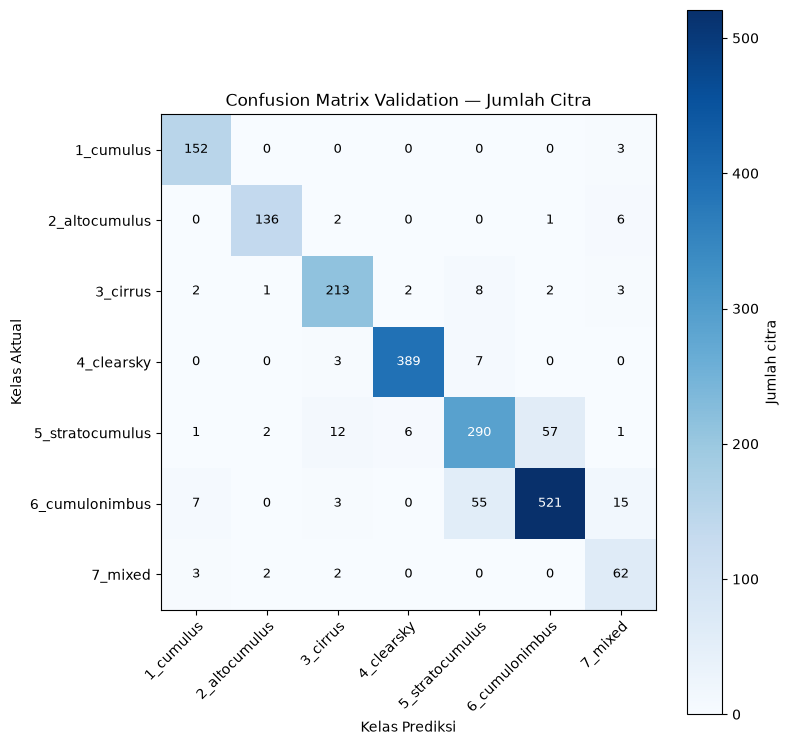

In [40]:
def plot_confusion_matrix(
    matrix: np.ndarray,
    class_names: list[str],
    title: str,
    value_format: str,
    colorbar_label: str,
    output_path: Path,
) -> None:
    """
    Membuat dan menyimpan confusion matrix menggunakan Matplotlib.
    """
    figure_size = max(
        8,
        int(NUM_CLASSES * 0.9),
    )

    fig, ax = plt.subplots(
        figsize=(
            figure_size,
            figure_size,
        )
    )

    image = ax.imshow(
        matrix,
        interpolation="nearest",
        cmap="Blues",
    )

    colorbar = fig.colorbar(
        image,
        ax=ax,
    )

    colorbar.set_label(
        colorbar_label
    )


    ax.set(
        title=title,
        xlabel="Kelas Prediksi",
        ylabel="Kelas Aktual",
        xticks=np.arange(NUM_CLASSES),
        yticks=np.arange(NUM_CLASSES),
        xticklabels=class_names,
        yticklabels=class_names,
    )


    plt.setp(
        ax.get_xticklabels(),
        rotation=45,
        ha="right",
        rotation_mode="anchor",
    )


    threshold = (
        float(matrix.max()) / 2.0
        if matrix.size
        else 0.0
    )


    for row_idx in range(NUM_CLASSES):
        for column_idx in range(NUM_CLASSES):
            value = matrix[
                row_idx,
                column_idx,
            ]

            ax.text(
                column_idx,
                row_idx,
                format(
                    value,
                    value_format,
                ),
                ha="center",
                va="center",
                color=(
                    "white"
                    if value > threshold
                    else "black"
                ),
                fontsize=9,
            )


    fig.tight_layout()

    fig.savefig(
        output_path,
        dpi=160,
        bbox_inches="tight",
    )

    plt.show()


plot_confusion_matrix(
    matrix=confusion_counts,
    class_names=CLASS_NAMES,
    title="Confusion Matrix Validation — Jumlah Citra",
    value_format="d",
    colorbar_label="Jumlah citra",
    output_path=CONFUSION_COUNTS_FIGURE_PATH,
)

,predicted_1_cumulus,predicted_2_altocumulus,predicted_3_cirrus,predicted_4_clearsky,predicted_5_stratocumulus,predicted_6_cumulonimbus,predicted_7_mixed
actual_1_cumulus,0.9806,0.0000,0.0000,0.0000,0.0000,0.0000,0.0194
actual_2_altocumulus,0.0000,0.9379,0.0138,0.0000,0.0000,0.0069,0.0414
actual_3_cirrus,0.0087,0.0043,0.9221,0.0087,0.0346,0.0087,0.0130
actual_4_clearsky,0.0000,0.0000,0.0075,0.9749,0.0175,0.0000,0.0000
actual_5_stratocumulus,0.0027,0.0054,0.0325,0.0163,0.7859,0.1545,0.0027
actual_6_cumulonimbus,0.0116,0.0000,0.0050,0.0000,0.0915,0.8669,0.0250
actual_7_mixed,0.0435,0.0290,0.0290,0.0000,0.0000,0.0000,0.8986


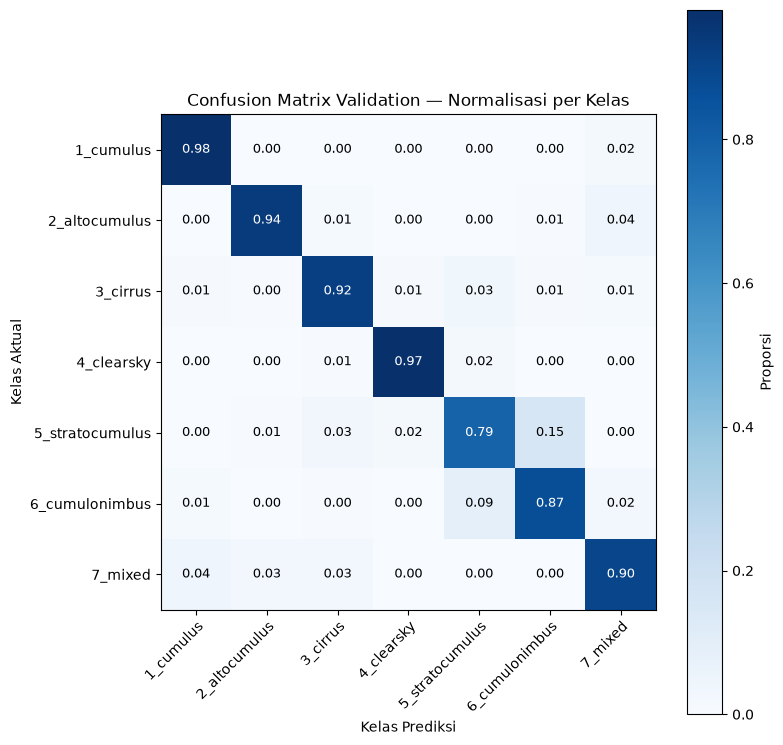

In [41]:
row_totals = confusion_counts.sum(
    axis=1,
    keepdims=True,
)


confusion_normalized = np.divide(
    confusion_counts,
    row_totals,
    out=np.zeros_like(
        confusion_counts,
        dtype=np.float64,
    ),
    where=row_totals != 0,
)


confusion_normalized_df = pd.DataFrame(
    confusion_normalized,
    index=[
        f"actual_{class_name}"
        for class_name in CLASS_NAMES
    ],
    columns=[
        f"predicted_{class_name}"
        for class_name in CLASS_NAMES
    ],
)


display(
    confusion_normalized_df.round(4)
)


plot_confusion_matrix(
    matrix=confusion_normalized,
    class_names=CLASS_NAMES,
    title="Confusion Matrix Validation — Normalisasi per Kelas",
    value_format=".2f",
    colorbar_label="Proporsi",
    output_path=CONFUSION_NORMALIZED_FIGURE_PATH,
)

## Pasangan Kelas yang Paling Sering Tertukar

Analisis ini hanya membaca nilai di luar diagonal confusion matrix. Hasilnya
dapat digunakan untuk mengetahui jenis awan yang memiliki karakter visual
serupa dan paling sulit dibedakan oleh model.

In [42]:
confused_pair_records = []


for actual_id in LABEL_IDS:
    for predicted_id in LABEL_IDS:
        if actual_id == predicted_id:
            continue

        error_count = int(
            confusion_counts[
                actual_id,
                predicted_id,
            ]
        )

        if error_count == 0:
            continue


        actual_total = int(
            confusion_counts[
                actual_id
            ].sum()
        )

        error_rate = (
            error_count / actual_total
            if actual_total > 0
            else 0.0
        )


        confused_pair_records.append({
            "actual_class_id": int(actual_id),
            "actual_class": IDX_TO_CLASS[int(actual_id)],
            "predicted_class_id": int(predicted_id),
            "predicted_class": IDX_TO_CLASS[int(predicted_id)],
            "error_count": error_count,
            "error_rate_within_actual_class": error_rate,
        })


confused_pairs_df = pd.DataFrame(
    confused_pair_records
)


if confused_pairs_df.empty:
    print(
        "Tidak terdapat pasangan kelas yang tertukar "
        "pada validation dataset."
    )

else:
    confused_pairs_df = (
        confused_pairs_df
        .sort_values(
            [
                "error_count",
                "error_rate_within_actual_class",
            ],
            ascending=[
                False,
                False,
            ],
        )
        .reset_index(drop=True)
    )

    display(
        confused_pairs_df
        .head(15)
        .round(6)
    )

,actual_class_id,actual_class,predicted_class_id,predicted_class,error_count,error_rate_within_actual_class
0,4,5_stratocumulus,5,6_cumulonimbus,57,0.154472
1,5,6_cumulonimbus,4,5_stratocumulus,55,0.091514
2,5,6_cumulonimbus,6,7_mixed,15,0.024958
3,4,5_stratocumulus,2,3_cirrus,12,0.032520
4,2,3_cirrus,4,5_stratocumulus,8,0.034632
5,3,4_clearsky,4,5_stratocumulus,7,0.017544
6,5,6_cumulonimbus,0,1_cumulus,7,0.011647
7,1,2_altocumulus,6,7_mixed,6,0.041379
8,4,5_stratocumulus,3,4_clearsky,6,0.016260
9,6,7_mixed,0,1_cumulus,3,0.043478


In [43]:
image_paths = [
    str(
        Path(image_path)
        .resolve()
        .relative_to(PROJECT_DIR)
    )
    for image_path, _
    in val_dataset.samples
]


sorted_probability_indices = np.argsort(
    -y_probability,
    axis=1,
)


second_prediction_ids = (
    sorted_probability_indices[:, 1]
)

maximum_confidence = y_probability[
    np.arange(len(y_pred)),
    y_pred,
]

true_class_probability = y_probability[
    np.arange(len(y_true)),
    y_true,
]

second_prediction_probability = y_probability[
    np.arange(len(y_pred)),
    second_prediction_ids,
]


prediction_df = pd.DataFrame({
    "image_path": image_paths,
    "true_class_id": y_true.astype(int),
    "true_class": [
        IDX_TO_CLASS[int(class_id)]
        for class_id in y_true
    ],
    "predicted_class_id": y_pred.astype(int),
    "predicted_class": [
        IDX_TO_CLASS[int(class_id)]
        for class_id in y_pred
    ],
    "correct": y_true == y_pred,
    "confidence": maximum_confidence,
    "true_class_probability": true_class_probability,
    "alternative_class": [
        IDX_TO_CLASS[int(class_id)]
        for class_id in second_prediction_ids
    ],
    "alternative_probability": second_prediction_probability,
})


display(
    prediction_df.head(10)
)

,image_path,true_class_id,true_class,predicted_class_id,predicted_class,correct,confidence,true_class_probability,alternative_class,alternative_probability
0,dataset\source\val\1_cumulus\1_cumulus_000004.jpg,0,1_cumulus,0,1_cumulus,True,0.970656,0.970656,7_mixed,0.019442
1,dataset\source\val\1_cumulus\1_cumulus_000008.jpg,0,1_cumulus,0,1_cumulus,True,0.907213,0.907213,7_mixed,0.063019
2,dataset\source\val\1_cumulus\1_cumulus_000010.jpg,0,1_cumulus,0,1_cumulus,True,0.837236,0.837236,7_mixed,0.066368
3,dataset\source\val\1_cumulus\1_cumulus_000011.jpg,0,1_cumulus,0,1_cumulus,True,0.892142,0.892142,7_mixed,0.053673
4,dataset\source\val\1_cumulus\1_cumulus_000015.jpg,0,1_cumulus,0,1_cumulus,True,0.963816,0.963816,7_mixed,0.016179
5,dataset\source\val\1_cumulus\1_cumulus_000018.jpg,0,1_cumulus,0,1_cumulus,True,0.817475,0.817475,3_cirrus,0.100361
6,dataset\source\val\1_cumulus\1_cumulus_000020.jpg,0,1_cumulus,0,1_cumulus,True,0.941519,0.941519,7_mixed,0.026124
7,dataset\source\val\1_cumulus\1_cumulus_000023.jpg,0,1_cumulus,0,1_cumulus,True,0.949372,0.949372,7_mixed,0.023149
8,dataset\source\val\1_cumulus\1_cumulus_000025.jpg,0,1_cumulus,0,1_cumulus,True,0.924702,0.924702,7_mixed,0.051578
9,dataset\source\val\1_cumulus\1_cumulus_000031.jpg,0,1_cumulus,0,1_cumulus,True,0.976961,0.976961,7_mixed,0.009284


## Analisis Confidence

Confidence merupakan probabilitas terbesar yang diberikan model pada setiap
citra.

Confidence tinggi tidak selalu berarti prediksi benar. Oleh karena itu,
prediksi salah dengan confidence tinggi perlu diperiksa secara khusus.

In [44]:
correct_mask = prediction_df[
    "correct"
].to_numpy()

incorrect_mask = ~correct_mask


confidence_summary_records = [
    {
        "Kelompok": "Semua prediksi",
        "Jumlah": len(prediction_df),
        "Rata-rata confidence": (
            prediction_df["confidence"].mean()
        ),
        "Median confidence": (
            prediction_df["confidence"].median()
        ),
    },
    {
        "Kelompok": "Prediksi benar",
        "Jumlah": int(correct_mask.sum()),
        "Rata-rata confidence": (
            prediction_df
            .loc[correct_mask, "confidence"]
            .mean()
        ),
        "Median confidence": (
            prediction_df
            .loc[correct_mask, "confidence"]
            .median()
        ),
    },
]


if incorrect_mask.any():
    confidence_summary_records.append({
        "Kelompok": "Prediksi salah",
        "Jumlah": int(incorrect_mask.sum()),
        "Rata-rata confidence": (
            prediction_df
            .loc[incorrect_mask, "confidence"]
            .mean()
        ),
        "Median confidence": (
            prediction_df
            .loc[incorrect_mask, "confidence"]
            .median()
        ),
    })


confidence_summary_df = pd.DataFrame(
    confidence_summary_records
)


display(
    confidence_summary_df.round(6)
)

,Kelompok,Jumlah,Rata-rata confidence,Median confidence
0,Semua prediksi,1969,0.728202,0.758890
1,Prediksi benar,1763,0.750939,0.778506
2,Prediksi salah,206,0.533617,0.510707


## Expected Calibration Error

Expected Calibration Error atau ECE membandingkan confidence rata-rata dengan
accuracy aktual pada beberapa interval confidence.

ECE yang lebih kecil menunjukkan bahwa probabilitas prediksi lebih sesuai
dengan tingkat kebenaran aktual. ECE tidak mengukur kemampuan klasifikasi secara
langsung dan harus dibaca bersama accuracy serta F1-score.

In [45]:
CALIBRATION_BINS = 10

bin_edges = np.linspace(
    0.0,
    1.0,
    CALIBRATION_BINS + 1,
)

bin_ids = np.digitize(
    maximum_confidence,
    bin_edges[1:-1],
    right=False,
)


reliability_records = []
expected_calibration_error = 0.0


for bin_id in range(CALIBRATION_BINS):
    current_mask = (
        bin_ids == bin_id
    )

    bin_count = int(
        current_mask.sum()
    )

    bin_lower = float(
        bin_edges[bin_id]
    )

    bin_upper = float(
        bin_edges[bin_id + 1]
    )


    if bin_count == 0:
        bin_accuracy = np.nan
        bin_confidence = np.nan
        absolute_gap = np.nan

    else:
        bin_accuracy = float(
            correct_mask[
                current_mask
            ].mean()
        )

        bin_confidence = float(
            maximum_confidence[
                current_mask
            ].mean()
        )

        absolute_gap = abs(
            bin_accuracy
            - bin_confidence
        )

        expected_calibration_error += (
            bin_count
            / len(y_true)
        ) * absolute_gap


    reliability_records.append({
        "bin_id": bin_id + 1,
        "confidence_lower": bin_lower,
        "confidence_upper": bin_upper,
        "sample_count": bin_count,
        "mean_confidence": bin_confidence,
        "bin_accuracy": bin_accuracy,
        "absolute_gap": absolute_gap,
    })


reliability_df = pd.DataFrame(
    reliability_records
)


display(
    reliability_df.round(6)
)

print(
    "Expected Calibration Error: "
    f"{expected_calibration_error:.6f}"
)

,bin_id,confidence_lower,confidence_upper,sample_count,mean_confidence,bin_accuracy,absolute_gap
0,1,0.0,0.1,0,NaN,NaN,NaN
1,2,0.1,0.2,0,NaN,NaN,NaN
2,3,0.2,0.3,11,0.279425,0.363636,0.084211
3,4,0.3,0.4,65,0.361259,0.600000,0.238741
4,5,0.4,0.5,171,0.450073,0.625731,0.175658
5,6,0.5,0.6,207,0.551459,0.787440,0.235981
6,7,0.6,0.7,281,0.651707,0.903915,0.252207
7,8,0.7,0.8,440,0.752252,0.931818,0.179566
8,9,0.8,0.9,484,0.845819,0.985537,0.139718
9,10,0.9,1.0,310,0.944074,0.996774,0.052700


Expected Calibration Error: 0.167176


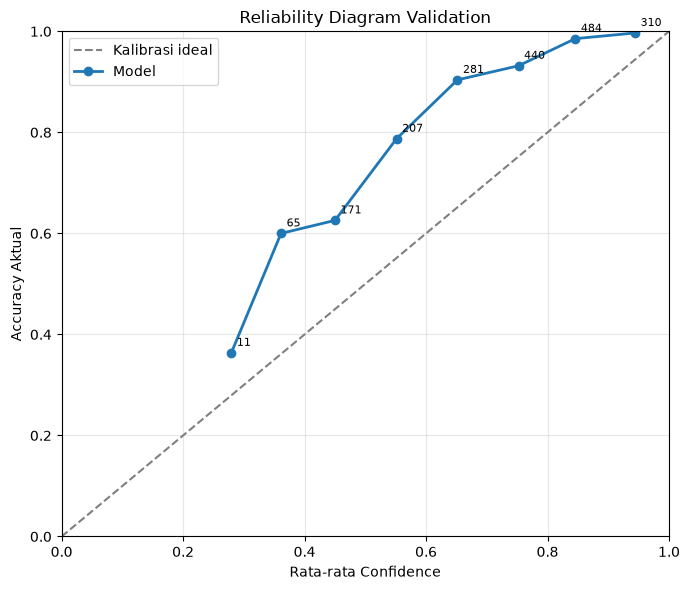

In [46]:
valid_reliability_df = reliability_df.dropna(
    subset=[
        "mean_confidence",
        "bin_accuracy",
    ]
)


fig, ax = plt.subplots(
    figsize=(7, 6)
)


ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Kalibrasi ideal",
)


ax.plot(
    valid_reliability_df["mean_confidence"],
    valid_reliability_df["bin_accuracy"],
    marker="o",
    linewidth=2,
    label="Model",
)


for _, row in valid_reliability_df.iterrows():
    ax.annotate(
        str(int(row["sample_count"])),
        (
            row["mean_confidence"],
            row["bin_accuracy"],
        ),
        xytext=(4, 5),
        textcoords="offset points",
        fontsize=8,
    )


ax.set_title(
    "Reliability Diagram Validation"
)

ax.set_xlabel(
    "Rata-rata Confidence"
)

ax.set_ylabel(
    "Accuracy Aktual"
)

ax.set_xlim(
    0.0,
    1.0,
)

ax.set_ylim(
    0.0,
    1.0,
)

ax.grid(
    alpha=0.3
)

ax.legend()

fig.tight_layout()

fig.savefig(
    RELIABILITY_FIGURE_PATH,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

## Prediksi Salah

Tabel berikut menampilkan seluruh prediksi salah. Data diurutkan berdasarkan
confidence tertinggi sehingga kesalahan model yang paling meyakinkan dapat
diperiksa terlebih dahulu.

In [47]:
error_df = (
    prediction_df
    .loc[
        ~prediction_df["correct"]
    ]
    .sort_values(
        "confidence",
        ascending=False,
    )
    .reset_index(drop=True)
)


error_rate = (
    len(error_df)
    / len(prediction_df)
)


print(f"Jumlah prediksi salah : {len(error_df):,}")
print(f"Error rate            : {error_rate:.4%}")


if error_df.empty:
    print(
        "Tidak ditemukan kesalahan prediksi "
        "pada validation dataset."
    )

else:
    display(
        error_df.head(20)
    )

Jumlah prediksi salah : 206
Error rate            : 10.4622%


,image_path,true_class_id,true_class,predicted_class_id,predicted_class,correct,confidence,true_class_probability,alternative_class,alternative_probability
0,dataset\source\val\6_cumulonimbus\6_cumulonimbus_001569.jpg,5,6_cumulonimbus,6,7_mixed,False,0.929510,0.053754,6_cumulonimbus,0.053754
1,dataset\source\val\3_cirrus\3_cirrus_000961.jpg,2,3_cirrus,6,7_mixed,False,0.862821,0.120646,3_cirrus,0.120646
2,dataset\source\val\1_cumulus\1_cumulus_000097.jpg,0,1_cumulus,6,7_mixed,False,0.845438,0.094702,1_cumulus,0.094702
3,dataset\source\val\3_cirrus\3_cirrus_001138.jpg,2,3_cirrus,6,7_mixed,False,0.834489,0.054574,2_altocumulus,0.073991
4,dataset\source\val\2_altocumulus\2_altocumulus_000613.jpg,1,2_altocumulus,6,7_mixed,False,0.826196,0.109669,2_altocumulus,0.109669
5,dataset\source\val\6_cumulonimbus\6_cumulonimbus_001560.jpg,5,6_cumulonimbus,6,7_mixed,False,0.825661,0.157825,6_cumulonimbus,0.157825
6,dataset\source\val\6_cumulonimbus\6_cumulonimbus_000481.jpg,5,6_cumulonimbus,4,5_stratocumulus,False,0.819370,0.086397,6_cumulonimbus,0.086397
7,dataset\source\val\5_stratocumulus\5_stratocumulus_001271.jpg,4,5_stratocumulus,5,6_cumulonimbus,False,0.812383,0.041785,7_mixed,0.106692
8,dataset\source\val\6_cumulonimbus\6_cumulonimbus_001536.jpg,5,6_cumulonimbus,4,5_stratocumulus,False,0.792142,0.073516,7_mixed,0.107301
9,dataset\source\val\3_cirrus\3_cirrus_001133.jpg,2,3_cirrus,6,7_mixed,False,0.782295,0.099375,2_altocumulus,0.099997


In [48]:
HIGH_CONFIDENCE_THRESHOLD = 0.80


high_confidence_errors_df = (
    error_df
    .loc[
        error_df["confidence"]
        >= HIGH_CONFIDENCE_THRESHOLD
    ]
    .reset_index(drop=True)
)


high_confidence_error_rate = (
    len(high_confidence_errors_df)
    / len(prediction_df)
)


high_confidence_summary = pd.DataFrame({
    "Parameter": [
        "Threshold confidence",
        "Jumlah seluruh kesalahan",
        "Kesalahan confidence tinggi",
        "Proporsi terhadap validation",
    ],
    "Nilai": [
        HIGH_CONFIDENCE_THRESHOLD,
        len(error_df),
        len(high_confidence_errors_df),
        high_confidence_error_rate,
    ],
})


display(
    high_confidence_summary.round(6)
)

,Parameter,Nilai
0,Threshold confidence,0.800000
1,Jumlah seluruh kesalahan,206.000000
2,Kesalahan confidence tinggi,8.000000
3,Proporsi terhadap validation,0.004063


## Visualisasi Kesalahan Prediksi

Citra asli dibaca langsung dari `dataset/source/val`. Transform normalisasi
tidak digunakan untuk visualisasi sehingga warna citra tetap sesuai dengan file
aslinya.

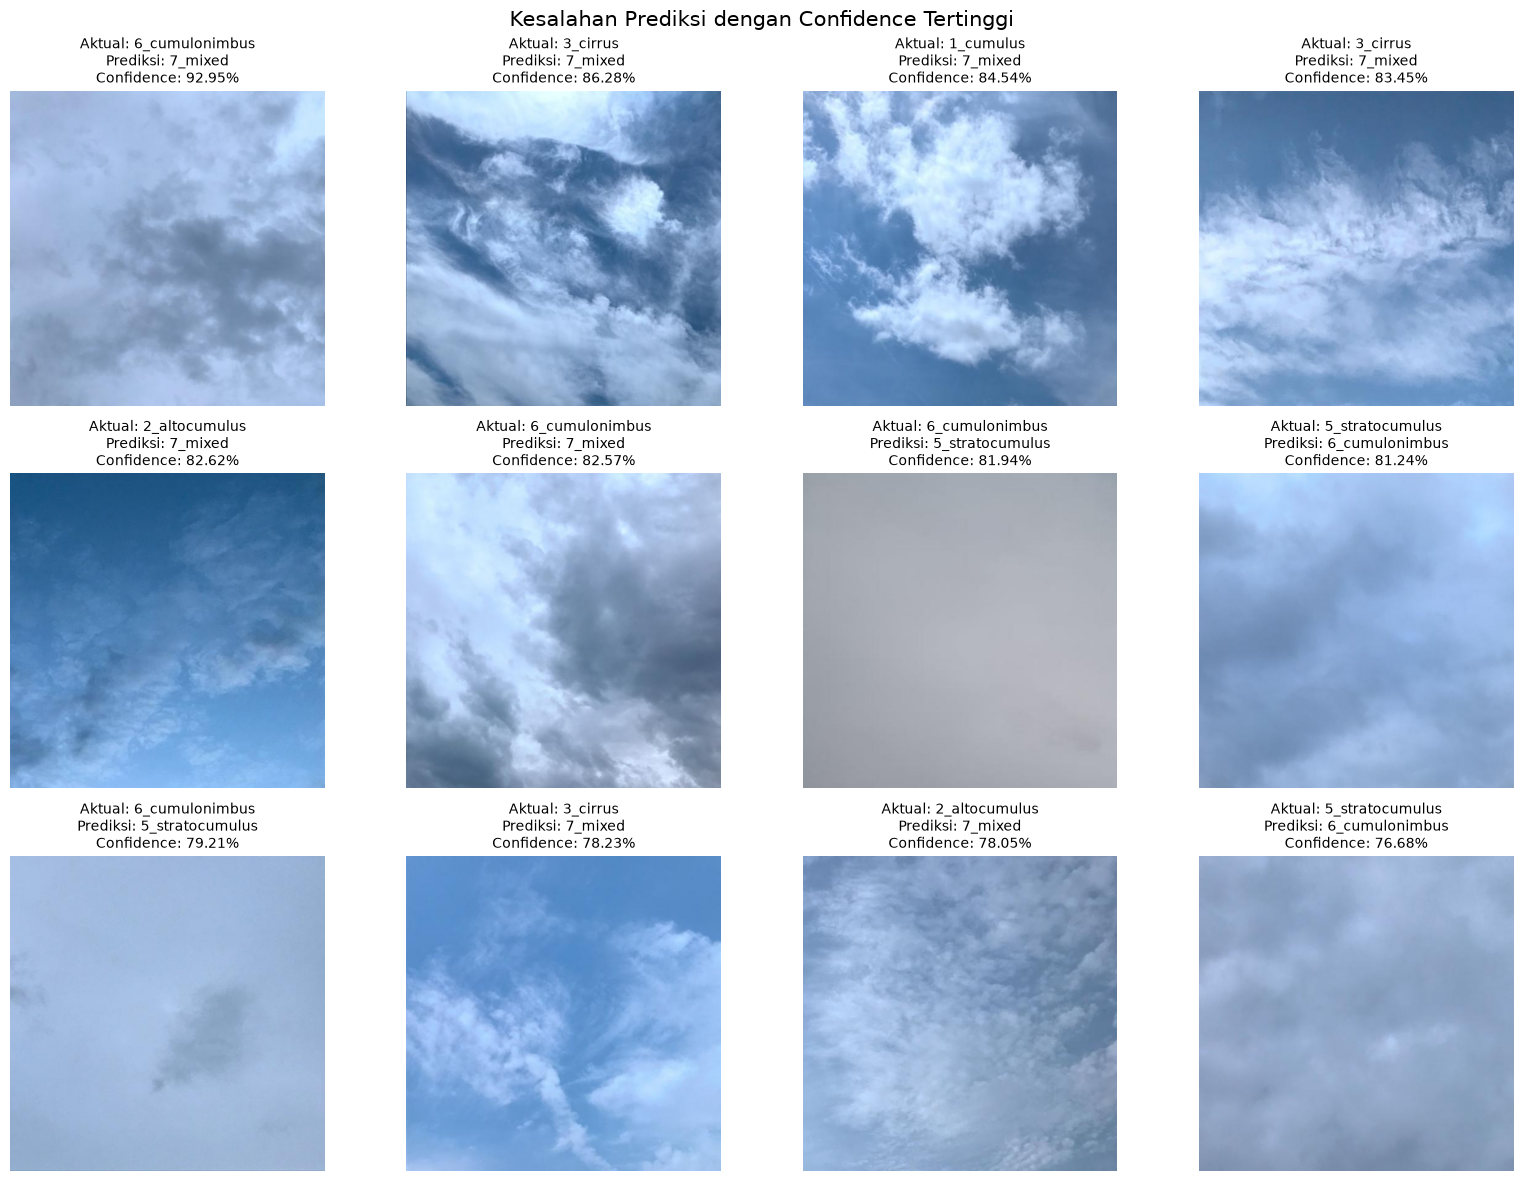

In [49]:
MAX_ERROR_IMAGES = 12


if error_df.empty:
    print(
        "Visualisasi tidak dibuat karena "
        "tidak terdapat prediksi salah."
    )

else:
    displayed_errors = (
        error_df
        .head(MAX_ERROR_IMAGES)
        .copy()
    )

    number_of_images = len(
        displayed_errors
    )

    number_of_columns = 4

    number_of_rows = int(
        np.ceil(
            number_of_images
            / number_of_columns
        )
    )


    fig, axes = plt.subplots(
        number_of_rows,
        number_of_columns,
        figsize=(
            16,
            number_of_rows * 4,
        ),
    )

    axes = np.atleast_1d(
        axes
    ).ravel()


    for axis, (_, row) in zip(
        axes,
        displayed_errors.iterrows(),
    ):
        image_path = (
            PROJECT_DIR
            / row["image_path"]
        )

        with Image.open(image_path) as image:
            axis.imshow(
                image.convert("RGB")
            )


        axis.set_title(
            f"Aktual: {row['true_class']}\n"
            f"Prediksi: {row['predicted_class']}\n"
            f"Confidence: {row['confidence']:.2%}",
            fontsize=10,
        )

        axis.axis("off")


    for axis in axes[number_of_images:]:
        axis.axis("off")


    fig.suptitle(
        "Kesalahan Prediksi dengan Confidence Tertinggi",
        fontsize=15,
    )

    fig.tight_layout()

    fig.savefig(
        ERROR_GRID_PATH,
        dpi=160,
        bbox_inches="tight",
    )

    plt.show()

## Distribusi Label Aktual dan Prediksi

Perbandingan distribusi membantu mendeteksi kecenderungan model terlalu sering
atau terlalu jarang memilih kelas tertentu.

,class_id,class_name,actual_count,predicted_count,count_difference
0,0,1_cumulus,155,165,10
1,1,2_altocumulus,145,141,-4
2,2,3_cirrus,231,235,4
3,3,4_clearsky,399,397,-2
4,4,5_stratocumulus,369,360,-9
5,5,6_cumulonimbus,601,581,-20
6,6,7_mixed,69,90,21


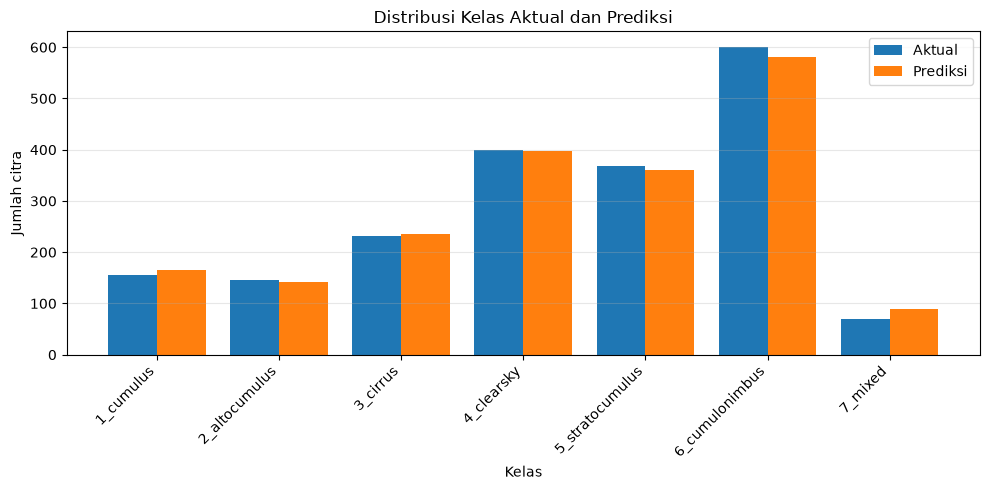

In [50]:
actual_counts = np.bincount(
    y_true,
    minlength=NUM_CLASSES,
)

predicted_counts = np.bincount(
    y_pred,
    minlength=NUM_CLASSES,
)


prediction_distribution_df = pd.DataFrame({
    "class_id": LABEL_IDS,
    "class_name": CLASS_NAMES,
    "actual_count": actual_counts,
    "predicted_count": predicted_counts,
    "count_difference": (
        predicted_counts
        - actual_counts
    ),
})


display(
    prediction_distribution_df
)


x_positions = np.arange(
    NUM_CLASSES
)

bar_width = 0.40


fig, ax = plt.subplots(
    figsize=(max(10, NUM_CLASSES * 1.2), 5)
)


ax.bar(
    x_positions - bar_width / 2,
    actual_counts,
    width=bar_width,
    label="Aktual",
)

ax.bar(
    x_positions + bar_width / 2,
    predicted_counts,
    width=bar_width,
    label="Prediksi",
)


ax.set_title(
    "Distribusi Kelas Aktual dan Prediksi"
)

ax.set_xlabel(
    "Kelas"
)

ax.set_ylabel(
    "Jumlah citra"
)

ax.set_xticks(
    x_positions
)

ax.set_xticklabels(
    CLASS_NAMES,
    rotation=45,
    ha="right",
)

ax.grid(
    axis="y",
    alpha=0.3,
)

ax.legend()

fig.tight_layout()

plt.show()

In [51]:
def finite_float_or_none(
    value,
):
    """
    Mengubah nilai numerik menjadi float yang kompatibel dengan JSON.
    """
    numeric_value = float(value)

    if not np.isfinite(numeric_value):
        return None

    return numeric_value


validation_summary = {
    "created_at": (
        datetime.now()
        .astimezone()
        .isoformat(timespec="seconds")
    ),
    "stage": "09_validasi_model",
    "validation_run_id": VALIDATION_RUN_ID,

    "model": {
        "model_name": MODEL_NAME,
        "num_classes": NUM_CLASSES,
        "input_shape": [
            INPUT_CHANNELS,
            IMAGE_HEIGHT,
            IMAGE_WIDTH,
        ],
        "dropout_rate": DROPOUT_RATE,
        "class_to_idx": CLASS_TO_IDX,
    },

    "checkpoint": {
        "path": str(
            BEST_CHECKPOINT_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "sha256": CHECKPOINT_SHA256,
        "phase": checkpoint["phase"],
        "global_epoch": int(
            checkpoint["global_epoch"]
        ),
        "saved_at": checkpoint.get(
            "saved_at"
        ),
    },

    "validation_data": {
        "path": str(
            VAL_DIR.relative_to(
                PROJECT_DIR
            )
        ),
        "number_of_images": int(
            len(val_dataset)
        ),
        "number_of_batches": int(
            len(val_loader)
        ),
        "batch_size": BATCH_SIZE,
        "class_distribution": {
            class_name: int(
                np.sum(
                    y_true == class_id
                )
            )
            for class_id, class_name
            in IDX_TO_CLASS.items()
        },
    },

    "metrics": {
        metric_name: finite_float_or_none(
            metric_value
        )
        for metric_name, metric_value
        in overall_metrics.items()
    },

    "confidence_intervals_95_percent": {
        "accuracy": {
            "estimate": float(accuracy),
            "lower": accuracy_ci_lower,
            "upper": accuracy_ci_upper,
        },
        "macro_f1": {
            "estimate": float(f1_macro),
            "lower": macro_f1_ci_lower,
            "upper": macro_f1_ci_upper,
        },
        "bootstrap_iterations": (
            BOOTSTRAP_ITERATIONS
        ),
    },

    "confidence_analysis": {
        "expected_calibration_error": float(
            expected_calibration_error
        ),
        "mean_confidence": float(
            maximum_confidence.mean()
        ),
        "high_confidence_threshold": (
            HIGH_CONFIDENCE_THRESHOLD
        ),
        "high_confidence_errors": int(
            len(high_confidence_errors_df)
        ),
    },

    "errors": {
        "number_of_errors": int(
            len(error_df)
        ),
        "error_rate": float(
            error_rate
        ),
    },

    "inference": {
        "device": str(DEVICE),
        "elapsed_seconds": float(
            validation_elapsed_seconds
        ),
        "images_per_second": float(
            len(val_dataset)
            / validation_elapsed_seconds
        ),
    },

    "data_usage": {
        "validation_data_used": True,
        "training_data_used": False,
        "test_data_used": False,
    },
}

## Menyimpan Artefak Validasi

Seluruh hasil disimpan pada folder log khusus proses validasi. Dataset dan
checkpoint tidak dimodifikasi.

In [52]:
overall_metrics_df.to_csv(
    SUMMARY_CSV_PATH,
    index=False,
    encoding="utf-8",
)

per_class_df.to_csv(
    PER_CLASS_PATH,
    index=False,
    encoding="utf-8",
)

prediction_df.to_csv(
    PREDICTIONS_PATH,
    index=False,
    encoding="utf-8",
)

error_df.to_csv(
    ERRORS_PATH,
    index=False,
    encoding="utf-8",
)

confusion_counts_df.to_csv(
    CONFUSION_COUNTS_PATH,
    index=True,
    encoding="utf-8",
)

confusion_normalized_df.to_csv(
    CONFUSION_NORMALIZED_PATH,
    index=True,
    encoding="utf-8",
)

reliability_df.to_csv(
    RELIABILITY_PATH,
    index=False,
    encoding="utf-8",
)


if confused_pairs_df.empty:
    pd.DataFrame(
        columns=[
            "actual_class_id",
            "actual_class",
            "predicted_class_id",
            "predicted_class",
            "error_count",
            "error_rate_within_actual_class",
        ]
    ).to_csv(
        CONFUSED_PAIRS_PATH,
        index=False,
        encoding="utf-8",
    )

else:
    confused_pairs_df.to_csv(
        CONFUSED_PAIRS_PATH,
        index=False,
        encoding="utf-8",
    )


with SUMMARY_JSON_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        validation_summary,
        file,
        indent=2,
        ensure_ascii=False,
        allow_nan=False,
    )


print("Artefak validasi berhasil disimpan.")

Artefak validasi berhasil disimpan.


In [53]:
artifact_records = [
    {
        "Artefak": "Ringkasan metrik CSV",
        "Path": SUMMARY_CSV_PATH,
    },
    {
        "Artefak": "Ringkasan validasi JSON",
        "Path": SUMMARY_JSON_PATH,
    },
    {
        "Artefak": "Metrik per kelas",
        "Path": PER_CLASS_PATH,
    },
    {
        "Artefak": "Seluruh prediksi",
        "Path": PREDICTIONS_PATH,
    },
    {
        "Artefak": "Prediksi salah",
        "Path": ERRORS_PATH,
    },
    {
        "Artefak": "Confusion matrix jumlah",
        "Path": CONFUSION_COUNTS_PATH,
    },
    {
        "Artefak": "Confusion matrix normalisasi",
        "Path": CONFUSION_NORMALIZED_PATH,
    },
    {
        "Artefak": "Gambar confusion matrix jumlah",
        "Path": CONFUSION_COUNTS_FIGURE_PATH,
    },
    {
        "Artefak": "Gambar confusion matrix normalisasi",
        "Path": CONFUSION_NORMALIZED_FIGURE_PATH,
    },
    {
        "Artefak": "Pasangan kelas tertukar",
        "Path": CONFUSED_PAIRS_PATH,
    },
    {
        "Artefak": "Reliability table",
        "Path": RELIABILITY_PATH,
    },
    {
        "Artefak": "Reliability diagram",
        "Path": RELIABILITY_FIGURE_PATH,
    },
]


if not error_df.empty:
    artifact_records.append({
        "Artefak": "Visualisasi kesalahan",
        "Path": ERROR_GRID_PATH,
    })


artifact_df = pd.DataFrame(
    artifact_records
)

artifact_df["Path"] = artifact_df["Path"].map(
    lambda path: str(
        path.relative_to(PROJECT_DIR)
    )
)

artifact_df["Ada"] = [
    (
        PROJECT_DIR
        / relative_path
    ).is_file()
    for relative_path
    in artifact_df["Path"]
]


display(artifact_df)

,Artefak,Path,Ada
0,Ringkasan metrik CSV,logs\resnet50_validation_20260826_231955\validation_summary.csv,True
1,Ringkasan validasi JSON,logs\resnet50_validation_20260826_231955\validation_summary.json,True
2,Metrik per kelas,logs\resnet50_validation_20260826_231955\validation_per_class.csv,True
3,Seluruh prediksi,logs\resnet50_validation_20260826_231955\validation_predictions.csv,True
4,Prediksi salah,logs\resnet50_validation_20260826_231955\validation_errors.csv,True
5,Confusion matrix jumlah,logs\resnet50_validation_20260826_231955\confusion_matrix_counts.csv,True
6,Confusion matrix normalisasi,logs\resnet50_validation_20260826_231955\confusion_matrix_normalized.csv,True
7,Gambar confusion matrix jumlah,logs\resnet50_validation_20260826_231955\confusion_matrix_counts.png,True
8,Gambar confusion matrix normalisasi,logs\resnet50_validation_20260826_231955\confusion_matrix_normalized.png,True
9,Pasangan kelas tertukar,logs\resnet50_validation_20260826_231955\most_confused_pairs.csv,True


## Pemeriksaan Akhir

Pemeriksaan akhir memastikan bahwa hasil validasi lengkap dan tidak ada data
test yang digunakan.

In [54]:
final_checks = {
    "Checkpoint terbaik tersedia": (
        BEST_CHECKPOINT_PATH.is_file()
    ),

    "Seluruh citra telah diprediksi": (
        len(prediction_df)
        == len(val_dataset)
    ),

    "Jumlah probabilitas sesuai": (
        y_probability.shape
        == (
            len(val_dataset),
            NUM_CLASSES,
        )
    ),

    "Probabilitas valid": (
        np.isfinite(
            y_probability
        ).all()
    ),

    "Jumlah probabilitas mendekati satu": (
        np.allclose(
            y_probability.sum(axis=1),
            1.0,
            atol=1e-5,
        )
    ),

    "Accuracy berada pada rentang valid": (
        0.0 <= accuracy <= 1.0
    ),

    "Macro F1 berada pada rentang valid": (
        0.0 <= f1_macro <= 1.0
    ),

    "Metrik per kelas lengkap": (
        len(per_class_df)
        == NUM_CLASSES
    ),

    "Ringkasan CSV tersimpan": (
        SUMMARY_CSV_PATH.is_file()
    ),

    "Ringkasan JSON tersimpan": (
        SUMMARY_JSON_PATH.is_file()
    ),

    "Prediksi tersimpan": (
        PREDICTIONS_PATH.is_file()
    ),

    "Confusion matrix tersimpan": (
        CONFUSION_COUNTS_PATH.is_file()
        and CONFUSION_NORMALIZED_PATH.is_file()
    ),

    "Data test tidak digunakan": (
        validation_summary[
            "data_usage"
        ][
            "test_data_used"
        ]
        is False
    ),

    "Bobot model tidak diperbarui": True,
}


final_check_df = pd.DataFrame({
    "Pemeriksaan": final_checks.keys(),
    "Status": [
        "Berhasil"
        if status
        else "Gagal"
        for status
        in final_checks.values()
    ],
})


display(final_check_df)


failed_checks = [
    check_name
    for check_name, status
    in final_checks.items()
    if not status
]


if failed_checks:
    formatted_checks = "\n".join(
        f"- {check_name}"
        for check_name in failed_checks
    )

    raise AssertionError(
        "Pemeriksaan akhir validasi gagal:\n"
        f"{formatted_checks}"
    )


print("Seluruh pemeriksaan akhir validasi berhasil.")

,Pemeriksaan,Status
0,Checkpoint terbaik tersedia,Berhasil
1,Seluruh citra telah diprediksi,Berhasil
2,Jumlah probabilitas sesuai,Berhasil
3,Probabilitas valid,Berhasil
4,Jumlah probabilitas mendekati satu,Berhasil
5,Accuracy berada pada rentang valid,Berhasil
6,Macro F1 berada pada rentang valid,Berhasil
7,Metrik per kelas lengkap,Berhasil
8,Ringkasan CSV tersimpan,Berhasil
9,Ringkasan JSON tersimpan,Berhasil


Seluruh pemeriksaan akhir validasi berhasil.


In [55]:
print("=" * 76)
print("VALIDASI MODEL SELESAI")
print("=" * 76)

print(f"Model                 : {MODEL_NAME}")
print(f"Checkpoint            : {BEST_CHECKPOINT_PATH.name}")
print(f"Fase checkpoint       : {checkpoint['phase']}")
print(f"Epoch checkpoint      : {checkpoint['global_epoch']}")
print(f"Jumlah data validation: {len(val_dataset):,}")
print(f"Jumlah kelas          : {NUM_CLASSES}")
print(f"Validation NLL        : {VALIDATION_NLL:.6f}")
print(f"Accuracy              : {accuracy:.4%}")
print(f"Balanced accuracy     : {balanced_accuracy:.4%}")
print(f"Macro precision       : {precision_macro:.4%}")
print(f"Macro recall          : {recall_macro:.4%}")
print(f"Macro F1-score        : {f1_macro:.4%}")
print(f"Weighted F1-score     : {f1_weighted:.4%}")
print(f"Cohen's Kappa         : {cohen_kappa:.6f}")
print(f"Matthews correlation  : {matthews_correlation:.6f}")

if np.isfinite(roc_auc):
    print(f"ROC-AUC OvR macro     : {roc_auc:.6f}")
else:
    print("ROC-AUC OvR macro     : Tidak tersedia")

if TOP_K is not None:
    print(
        f"Top-{TOP_K} accuracy        : "
        f"{top_k_accuracy:.4%}"
    )

print(
    f"Accuracy CI 95%       : "
    f"[{accuracy_ci_lower:.4%}, "
    f"{accuracy_ci_upper:.4%}]"
)

print(
    f"Macro F1 CI 95%       : "
    f"[{macro_f1_ci_lower:.4%}, "
    f"{macro_f1_ci_upper:.4%}]"
)

print(
    f"Calibration error     : "
    f"{expected_calibration_error:.6f}"
)

print(f"Jumlah prediksi salah : {len(error_df):,}")
print(f"Data test digunakan   : Tidak")

print(
    "Folder hasil          : "
    f"{VALIDATION_RUN_DIR.relative_to(PROJECT_DIR)}"
)

print("=" * 76)

VALIDASI MODEL SELESAI
Model                 : resnet50
Checkpoint            : resnet50_gcd_best.pth
Fase checkpoint       : finetune_all
Epoch checkpoint      : 20
Jumlah data validation: 1,969
Jumlah kelas          : 7
Validation NLL        : 0.450861
Accuracy              : 89.5378%
Balanced accuracy     : 90.9563%
Macro precision       : 88.0451%
Macro recall          : 90.9563%
Macro F1-score        : 89.2806%
Weighted F1-score     : 89.5637%
Cohen's Kappa         : 0.870412
Matthews correlation  : 0.870566
ROC-AUC OvR macro     : 0.989393
Top-3 accuracy        : 99.3398%
Accuracy CI 95%       : [88.1666%, 90.7567%]
Macro F1 CI 95%       : [87.6419%, 90.7316%]
Calibration error     : 0.167176
Jumlah prediksi salah : 206
Data test digunakan   : Tidak
Folder hasil          : logs\resnet50_validation_20260826_231955


## Panduan Interpretasi

Hasil validasi perlu dibaca secara bersama-sama.

1. **Accuracy** menggambarkan performa keseluruhan, tetapi dapat dipengaruhi
   ketidakseimbangan kelas.

2. **Balanced accuracy** lebih tepat digunakan ketika jumlah citra setiap kelas
   tidak sama.

3. **Macro F1-score** memberikan bobot yang sama kepada setiap kelas. Metrik ini
   penting untuk menilai apakah model hanya memiliki performa baik pada kelas
   mayoritas.

4. **Weighted F1-score** mempertimbangkan jumlah sampel setiap kelas. Nilai yang
   jauh lebih tinggi daripada macro F1 dapat menunjukkan bahwa kelas dengan
   jumlah sampel besar lebih mudah dikenali.

5. **Recall per kelas** menunjukkan kemampuan model menemukan seluruh citra
   yang benar-benar berasal dari kelas tersebut.

6. **Precision per kelas** menunjukkan ketepatan model ketika memberikan suatu
   label kelas.

7. **Confusion matrix** digunakan untuk mengidentifikasi pasangan jenis awan
   yang paling sering tertukar.

8. **Expected Calibration Error** menilai kesesuaian confidence dengan tingkat
   kebenaran prediksi. Nilai lebih kecil menunjukkan kalibrasi yang lebih baik.

9. **Kesalahan dengan confidence tinggi** perlu diperiksa karena dapat berasal
   dari kemiripan visual, label yang ambigu, citra berkualitas rendah, atau
   keterbatasan representasi model.

10. Hasil validation tidak boleh dinyatakan sebagai performa generalisasi final
    karena split validation sudah digunakan untuk pemilihan checkpoint dan
    early stopping.

## Kesimpulan

Tahap validasi model klasifikasi jenis awan telah selesai.

Hasil utama:

1. Konfigurasi model dan DataLoader dibaca dari artefak notebook sebelumnya.
2. Preprocessing evaluasi dimuat dari `eval_transform.json`.
3. Validation dataset dibentuk tanpa menggunakan augmentasi training.
4. Pemetaan kelas disesuaikan dengan `model_config.json`.
5. Checkpoint terbaik dimuat tanpa mengunduh ulang bobot pretrained.
6. Seluruh citra validation diproses dengan `shuffle=False` dan
   `drop_last=False`.
7. Validation NLL, accuracy, balanced accuracy, precision, recall, dan F1-score
   berhasil dihitung.
8. Cohen's Kappa, Matthews Correlation Coefficient, ROC-AUC, dan top-k accuracy
   dihitung sebagai metrik tambahan.
9. Confidence interval accuracy dan macro F1 dihitung menggunakan stratified
   bootstrap.
10. Metrik setiap kelas dan confusion matrix berhasil dibuat.
11. Pasangan kelas yang paling sering tertukar berhasil diidentifikasi.
12. Confidence dan Expected Calibration Error berhasil dianalisis.
13. Prediksi salah dengan confidence tertinggi berhasil dicatat dan
    divisualisasikan.
14. Seluruh hasil validasi disimpan pada folder `logs`.
15. Bobot model tidak diperbarui.
16. Training dataset tidak digunakan.
17. Test dataset tidak digunakan.

Artefak utama yang dihasilkan:

- `validation_summary.csv`
- `validation_summary.json`
- `validation_per_class.csv`
- `validation_predictions.csv`
- `validation_errors.csv`
- `confusion_matrix_counts.csv`
- `confusion_matrix_normalized.csv`
- `confusion_matrix_counts.png`
- `confusion_matrix_normalized.png`
- `most_confused_pairs.csv`
- `confidence_reliability.csv`
- `confidence_reliability.png`
- `high_confidence_errors.png`, apabila terdapat kesalahan prediksi.

Tahap selanjutnya adalah membuat `10_evaluasi_model.ipynb`.

Pada tahap tersebut, checkpoint yang sudah ditetapkan akan diuji satu kali
menggunakan:

```text
dataset/source/test/